London Carpool Connect - Baseline Matching Algorithm

In this notebook I build the first version of my passenger-driver matching algorithm.

This version uses straight-line distance between coordinates. It is not as realistic as a road-route model, but it is fast, explainable and useful as a baseline.


In [1]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
from datetime import datetime

In [2]:
passengers = pd.read_csv("/content/passengers.csv")
drivers = pd.read_csv("/content/drivers.csv")
locations = pd.read_csv("/content/LondonLocationsDataset.csv")

print("Passengers:", passengers.shape)
print("Drivers:", drivers.shape)
print("Locations:", locations.shape)

Passengers: (50, 16)
Drivers: (20, 17)
Locations: (30, 5)


In [3]:
passengers.head()

,passenger_id,passenger_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,preferred_time,time_flexibility_mins,max_pickup_distance_km,max_detour_mins,requires_accessibility,status
0,P001,William Jennings,Wimbledon,51.4214,-0.2064,South West,Camden,51.5390,-0.1426,North,09:30,5,0.5,20,False,unmatched
1,P002,Lesley Wilson-Newman,Bank,51.5133,-0.0896,Central,Canary Wharf,51.5054,-0.0235,East,07:45,10,1.0,20,True,unmatched
2,P003,Abdul Hopkins,Richmond,51.4613,-0.3037,South West,London Bridge,51.5079,-0.0877,Central,09:30,5,2.0,10,True,unmatched
3,P004,Mrs Lauren Green,Paddington,51.5154,-0.1755,West,Ealing,51.5130,-0.3089,West,07:15,10,1.0,20,True,unmatched
4,P005,Tina Foster,London Bridge,51.5079,-0.0877,Central,Waterloo,51.5036,-0.1143,Central,09:00,10,2.0,10,False,unmatched


In [4]:
drivers.head()

,driver_id,driver_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,departure_time,time_flexibility_mins,seats_available,vehicle_type,max_detour_mins,accepts_accessibility,status
0,D001,Joshua Stewart,Peckham,51.4742,-0.0697,South East,Wembley,51.5560,-0.2795,North West,08:00,10,3,Electric,30,False,available
1,D002,Philip Clarke,Hackney,51.5450,-0.0553,East,Greenwich,51.4826,0.0077,South East,08:45,5,2,Hybrid,15,True,available
2,D003,Henry O'Brien,Croydon,51.3762,-0.0982,South,Peckham,51.4742,-0.0697,South East,09:15,15,1,Hybrid,10,True,available
3,D004,Leon Davison,Tottenham,51.5888,-0.0726,North,London Bridge,51.5079,-0.0877,Central,09:15,10,2,Petrol,30,True,available
4,D005,Kayleigh Mitchell,Wimbledon,51.4214,-0.2064,South West,London Bridge,51.5079,-0.0877,Central,07:30,5,1,Diesel,25,True,available


In [26]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Calculates straight-line distance between two latitude/longitude points.Output is in kilometres.

    R = 6371  # Radius of Earth in km

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c

    return distance

In [6]:
camden = locations[locations["location"] == "Camden"].iloc[0]
canary_wharf = locations[locations["location"] == "Canary Wharf"].iloc[0]

distance = haversine_distance(
    camden["latitude"],
    camden["longitude"],
    canary_wharf["latitude"],
    canary_wharf["longitude"]
)

print("Distance from Camden to Canary Wharf:", round(distance, 2), "km")

Distance from Camden to Canary Wharf: 9.05 km


In [27]:
def time_difference_minutes(time1, time2):
    # Calculates the difference between two HH:MM times in minutes.

    t1 = datetime.strptime(time1, "%H:%M")
    t2 = datetime.strptime(time2, "%H:%M")

    difference = abs((t1 - t2).total_seconds() / 60)

    return difference

In [8]:
print(time_difference_minutes("08:00", "08:15"))
print(time_difference_minutes("07:30", "09:00"))

15.0
90.0


In [28]:
def calculate_match_score(passenger, driver):
    # Calculates a match score between one passenger and one driver. Score is between 0 and 100.

    # Seat availability check
    if driver["seats_available"] <= 0:
        return 0

    # Accessibility check
    if passenger["requires_accessibility"] == True and driver["accepts_accessibility"] == False:
        return 0

    # Time compatibility
    time_diff = time_difference_minutes(
        passenger["preferred_time"],
        driver["departure_time"]
    )

    allowed_time_diff = passenger["time_flexibility_mins"] + driver["time_flexibility_mins"]

    if time_diff > allowed_time_diff:
        time_score = 0
    else:
        time_score = 100 - ((time_diff / allowed_time_diff) * 100)

    # Origin closeness
    origin_distance = haversine_distance(
        passenger["origin_lat"],
        passenger["origin_lon"],
        driver["origin_lat"],
        driver["origin_lon"]
    )

    if origin_distance > passenger["max_pickup_distance_km"] + 5:
        origin_score = 0
    else:
        origin_score = max(0, 100 - (origin_distance * 10))

    # Destination closeness
    destination_distance = haversine_distance(
        passenger["destination_lat"],
        passenger["destination_lon"],
        driver["destination_lat"],
        driver["destination_lon"]
    )

    if destination_distance > 10:
        destination_score = 0
    else:
        destination_score = max(0, 100 - (destination_distance * 10))

    # Same-zone bonus
    same_origin_zone = passenger["origin_zone"] == driver["origin_zone"]
    same_destination_zone = passenger["destination_zone"] == driver["destination_zone"]

    zone_score = 0

    if same_origin_zone:
        zone_score += 50

    if same_destination_zone:
        zone_score += 50

    # Vehicle sustainability score
    vehicle_type = driver["vehicle_type"]

    if vehicle_type == "Electric":
        sustainability_score = 100
    elif vehicle_type == "Hybrid":
        sustainability_score = 80
    elif vehicle_type == "Petrol":
        sustainability_score = 50
    else:
        sustainability_score = 40

    # Final weighted score
    final_score = (
        0.30 * time_score +
        0.25 * origin_score +
        0.25 * destination_score +
        0.10 * zone_score +
        0.10 * sustainability_score
    )

    return round(final_score, 2)

In [10]:
test_passenger = passengers.iloc[0]
test_driver = drivers.iloc[0]

score = calculate_match_score(test_passenger, test_driver)

print("Passenger:", test_passenger["passenger_id"], test_passenger["origin"], "to", test_passenger["destination"])
print("Driver:", test_driver["driver_id"], test_driver["origin"], "to", test_driver["destination"])
print("Match score:", score)

Passenger: P001 Wimbledon to Camden
Driver: D001 Peckham to Wembley
Match score: 10.87


In [29]:
def classify_match(score):
    # Converts numerical score into a readable match category.

    if score >= 80:
        return "Excellent match"
    elif score >= 60:
        return "Good match"
    elif score >= 40:
        return "Weak match"
    else:
        return "Not recommended"

In [12]:
print(classify_match(85))
print(classify_match(65))
print(classify_match(45))
print(classify_match(20))

Excellent match
Good match
Weak match
Not recommended


In [30]:
def find_matches_for_passenger(passenger, drivers_df, top_n=5):
    # Finds the top matching drivers for one passenger.

    match_results = []

    for _, driver in drivers_df.iterrows():
        score = calculate_match_score(passenger, driver)

        result = {
            "passenger_id": passenger["passenger_id"],
            "passenger_name": passenger["passenger_name"],
            "passenger_origin": passenger["origin"],
            "passenger_destination": passenger["destination"],
            "passenger_time": passenger["preferred_time"],
            "driver_id": driver["driver_id"],
            "driver_name": driver["driver_name"],
            "driver_origin": driver["origin"],
            "driver_destination": driver["destination"],
            "driver_time": driver["departure_time"],
            "driver_vehicle_type": driver["vehicle_type"],
            "driver_seats_available": driver["seats_available"],
            "match_score": score,
            "match_category": classify_match(score)
        }

        match_results.append(result)

    matches_df = pd.DataFrame(match_results)

    matches_df = matches_df.sort_values(
        by="match_score",
        ascending=False
    )

    return matches_df.head(top_n)

In [14]:
passenger_1 = passengers.iloc[0]
top_matches = find_matches_for_passenger(passenger_1, drivers, top_n=5)
top_matches

,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,match_score,match_category
18,P001,William Jennings,Wimbledon,Camden,09:30,D019,Dr Joan Taylor,Wimbledon,Tottenham,07:30,Hybrid,1,49.62,Weak match
8,P001,William Jennings,Wimbledon,Camden,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,47.99,Weak match
4,P001,William Jennings,Wimbledon,Camden,09:30,D005,Kayleigh Mitchell,Wimbledon,London Bridge,07:30,Diesel,1,46.16,Weak match
16,P001,William Jennings,Wimbledon,Camden,09:30,D017,Dr Dennis Bates,Paddington,Islington,07:00,Diesel,3,27.30,Not recommended
17,P001,William Jennings,Wimbledon,Camden,09:30,D018,Lydia Williams,Shoreditch,King's Cross,08:45,Petrol,4,26.03,Not recommended


In [31]:
def find_matches_for_all_passengers(passengers_df, drivers_df, top_n=3):
    # Finds top matching drivers for every passenger.

    all_matches = []

    for _, passenger in passengers_df.iterrows():
        passenger_matches = find_matches_for_passenger(
            passenger,
            drivers_df,
            top_n=top_n
        )

        all_matches.append(passenger_matches)

    all_matches_df = pd.concat(all_matches, ignore_index=True)

    return all_matches_df

In [16]:
all_matches = find_matches_for_all_passengers(passengers, drivers, top_n=3)
all_matches.head(10)

,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,match_score,match_category
0,P001,William Jennings,Wimbledon,Camden,09:30,D019,Dr Joan Taylor,Wimbledon,Tottenham,07:30,Hybrid,1,49.62,Weak match
1,P001,William Jennings,Wimbledon,Camden,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,47.99,Weak match
2,P001,William Jennings,Wimbledon,Camden,09:30,D005,Kayleigh Mitchell,Wimbledon,London Bridge,07:30,Diesel,1,46.16,Weak match
3,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D013,Maria Bruce,King's Cross,Clapham,08:00,Hybrid,1,44.25,Weak match
4,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D011,Sarah Hammond,King's Cross,Waterloo,09:00,Hybrid,2,39.62,Not recommended
5,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D002,Philip Clarke,Hackney,Greenwich,08:45,Hybrid,2,39.05,Not recommended
6,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,47.88,Weak match
7,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D005,Kayleigh Mitchell,Wimbledon,London Bridge,07:30,Diesel,1,39.00,Not recommended
8,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D004,Leon Davison,Tottenham,London Bridge,09:15,Petrol,2,35.00,Not recommended
9,P004,Mrs Lauren Green,Paddington,Ealing,07:15,D017,Dr Dennis Bates,Paddington,Islington,07:00,Diesel,3,34.00,Not recommended


In [17]:
all_matches.shape

(150, 14)

In [18]:
recommended_matches = all_matches[all_matches["match_score"] >= 60]
recommended_matches.head()

,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,match_score,match_category
12,P005,Tina Foster,London Bridge,Waterloo,09:00,D011,Sarah Hammond,King's Cross,Waterloo,09:00,Hybrid,2,89.08,Excellent match
21,P008,Sarah Reed-Walsh,Hackney,Lewisham,07:15,D002,Philip Clarke,Hackney,Greenwich,08:45,Hybrid,2,61.29,Good match
27,P010,Dr Lee Green,Westminster,Southwark,09:00,D011,Sarah Hammond,King's Cross,Waterloo,09:00,Hybrid,2,82.65,Excellent match
39,P014,Mrs Julia Harris,Canary Wharf,Bank,07:30,D005,Kayleigh Mitchell,Wimbledon,London Bridge,07:30,Diesel,1,62.46,Good match
42,P015,Dylan Young,Hackney,Croydon,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,61.08,Good match


In [19]:
print("Total matches:", len(all_matches))
print("Recommended matches:", len(recommended_matches))

Total matches: 150
Recommended matches: 16


In [20]:
best_matches = (
    all_matches
    .sort_values(by=["passenger_id", "match_score"], ascending=[True, False])
    .groupby("passenger_id")
    .head(1)
    .reset_index(drop=True)
)

best_matches.head()

,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,match_score,match_category
0,P001,William Jennings,Wimbledon,Camden,09:30,D019,Dr Joan Taylor,Wimbledon,Tottenham,07:30,Hybrid,1,49.62,Weak match
1,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D013,Maria Bruce,King's Cross,Clapham,08:00,Hybrid,1,44.25,Weak match
2,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,47.88,Weak match
3,P004,Mrs Lauren Green,Paddington,Ealing,07:15,D017,Dr Dennis Bates,Paddington,Islington,07:00,Diesel,3,34.00,Not recommended
4,P005,Tina Foster,London Bridge,Waterloo,09:00,D011,Sarah Hammond,King's Cross,Waterloo,09:00,Hybrid,2,89.08,Excellent match


In [21]:
best_matches["final_status"] = np.where(
    best_matches["match_score"] >= 60,
    "matched",
    "unmatched"
)

best_matches.head()

,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,match_score,match_category,final_status
0,P001,William Jennings,Wimbledon,Camden,09:30,D019,Dr Joan Taylor,Wimbledon,Tottenham,07:30,Hybrid,1,49.62,Weak match,unmatched
1,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D013,Maria Bruce,King's Cross,Clapham,08:00,Hybrid,1,44.25,Weak match,unmatched
2,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,47.88,Weak match,unmatched
3,P004,Mrs Lauren Green,Paddington,Ealing,07:15,D017,Dr Dennis Bates,Paddington,Islington,07:00,Diesel,3,34.00,Not recommended,unmatched
4,P005,Tina Foster,London Bridge,Waterloo,09:00,D011,Sarah Hammond,King's Cross,Waterloo,09:00,Hybrid,2,89.08,Excellent match,matched


In [22]:
total_passengers = len(passengers)
matched_passengers = len(best_matches[best_matches["final_status"] == "matched"])
unmatched_passengers = total_passengers - matched_passengers

match_rate = (matched_passengers / total_passengers) * 100
average_score = best_matches["match_score"].mean()

print("Total passengers:", total_passengers)
print("Matched passengers:", matched_passengers)
print("Unmatched passengers:", unmatched_passengers)
print("Match rate:", round(match_rate, 2), "%")
print("Average match score:", round(average_score, 2))

Total passengers: 50
Matched passengers: 14
Unmatched passengers: 36
Match rate: 28.0 %
Average match score: 52.64


In [23]:
all_matches.to_csv("all_matches.csv", index=False)
best_matches.to_csv("best_matches.csv", index=False)
recommended_matches.to_csv("recommended_matches.csv", index=False)

<Axes: title={'center': 'Matched vs Unmatched Passengers'}, xlabel='final_status'>

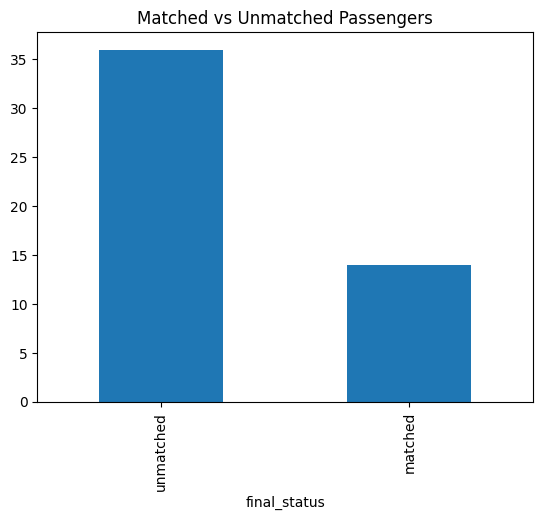

In [24]:
best_matches["final_status"].value_counts().plot(
    kind="bar",
    title="Matched vs Unmatched Passengers"
)

<Axes: title={'center': 'Distribution of Match Scores'}, ylabel='Frequency'>

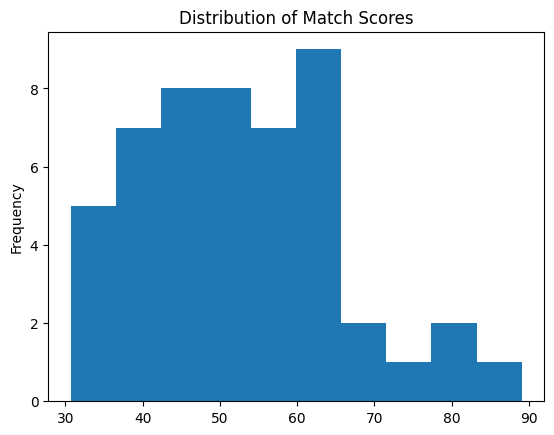

In [25]:
best_matches["match_score"].plot(
    kind="hist",
    bins=10,
    title="Distribution of Match Scores"
)